## 09. Evaluacija i finalno poređenje modela

Ovaj notebook agrerira rezultate iz notebook-a 04, 06, 07 i 08 i vrši finalno poređenje sva 4 eksperimenta:

- **Eksperiment A**: SC + klasični ML (04)
- **Eksperiment B**: SC + Deep Learning / ESM-2 (06)
- **Eksperiment C**: MC + klasični ML (07)
- **Eksperiment D**: MC + Deep Learning / ESM-2 (08)

In [2]:
import os
import json
import joblib
import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, hamming_loss
)

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Koristi se uredjaj: {DEVICE}")

Koristi se uredjaj: cpu


### Konfiguracija i putanje

In [3]:
DATA_DIR = "../data/processed"
FEATURES_DIR = "../data/features"
MODELS_DIR = "../data/models"
RESULTS_DIR = "../data/results"

os.makedirs(RESULTS_DIR, exist_ok=True)

## Eksperiment A: SC + klasični ML (notebook 04)


In [ ]:
sc_classical_results = pd.read_csv(os.path.join(RESULTS_DIR, "sc_classical_modeling_results.csv"))
best_sc_classical = sc_classical_results.sort_values("CV F1 (weighted)", ascending=False).iloc[0]

print(f"Najbolja kombinacija: {best_sc_classical['Model']} + {best_sc_classical['Feature set']}")
print(f"Parametri: {best_sc_classical['Best params']}\n")

Najbolja kombinacija: SVM + AAC-CV+TFIDF-SVD
Parametri: {'C': 10, 'kernel': 'rbf'}



### Rekonstrukcija SC test obilježja

In [9]:
train_entries_df = pd.read_csv(os.path.join(FEATURES_DIR, "sc_train_entries.csv"))
test_entries_df = pd.read_csv(os.path.join(FEATURES_DIR, "sc_test_entries.csv"))

entries_sc_test = test_entries_df["Entry"].values
y_sc_test = test_entries_df["label_encoded"].values

# LabelEncoder fitovan jednom u 03 (nema ponovnog fitovanja)
le = joblib.load(os.path.join(FEATURES_DIR, "sc_label_encoder.pkl"))

# AAC-CV (fiksni vokabular, isti za sve podskupove)
aac_df = pd.read_csv(os.path.join(FEATURES_DIR, "aac_cv_features.csv"), index_col="Entry")
sc_test_aac = aac_df.loc[entries_sc_test].values

# TF-IDF+SVD i PH, fitovani na SC train skupu u 03
sc_test_tfidf = np.load(os.path.join(FEATURES_DIR, "sc_test_tfidf_svd.npy"))
sc_test_ph = np.load(os.path.join(FEATURES_DIR, "sc_test_physchem_scaled.npy"))

feature_sets_test_sc = {
    "AAC-CV": sc_test_aac,
    "TFIDF-SVD": sc_test_tfidf,
    "PH": sc_test_ph,
    "AAC-CV+TFIDF-SVD": np.hstack([sc_test_aac, sc_test_tfidf]),
    "AAC-CV+PH": np.hstack([sc_test_aac, sc_test_ph]),
    "TFIDF-SVD+PH": np.hstack([sc_test_tfidf, sc_test_ph]),
    "AAC-CV+TFIDF-SVD+PH": np.hstack([sc_test_aac, sc_test_tfidf, sc_test_ph]),
}

print(f"Test skup (SC): {len(entries_sc_test)} proteina")

Test skup (SC): 1333 proteina


### Finalni classification report 

In [20]:
best_sc_model_path = os.path.join(
    MODELS_DIR, f"sc_{best_sc_classical['Model']}_{best_sc_classical['Feature set']}.pkl"
)

best_sc_classical_model = joblib.load(best_sc_model_path)
X_test_best_sc = feature_sets_test_sc[best_sc_classical["Feature set"]]

y_pred_sc_classical= best_sc_classical_model.predict(X_test_best_sc)

print(f"Eksperiment A: {best_sc_classical['Model']} + {best_sc_classical['Feature set']} \n")
print(classification_report(y_sc_test, y_pred_sc_classical, target_names=le.classes_))

Eksperiment A: SVM + AAC-CV+TFIDF-SVD 

                      precision    recall  f1-score   support

           Hydrolase       0.78      0.87      0.82       441
            Receptor       0.86      0.86      0.86       276
  Structural protein       0.80      0.61      0.69       142
Transcription factor       0.90      0.92      0.91       269
   Transport protein       0.76      0.67      0.71       205

            accuracy                           0.82      1333
           macro avg       0.82      0.78      0.80      1333
        weighted avg       0.82      0.82      0.82      1333



### Matrica konfuzije

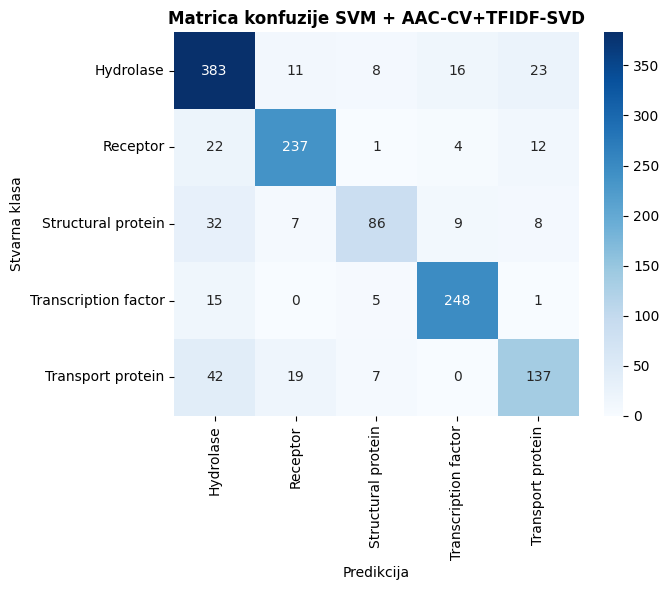

In [38]:
cm = confusion_matrix(y_sc_test, y_pred_sc_classical)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=le.classes_, yticklabels=le.classes_
)
plt.title(f"Matrica konfuzije {best_sc_classical['Model']} + {best_sc_classical['Feature set']}", fontweight="bold")
plt.xlabel("Predikcija")
plt.ylabel("Stvarna klasa")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "fig_classical_sc_confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()

## Eksperiment B: SC + Deep Learning (notebook 06)

In [14]:
def build_mlp(input_dim, num_classes, hidden_dims, dropout):
    layers = []
    prev_dim = input_dim
    for h in hidden_dims:
        layers.extend([
            nn.Linear(prev_dim, h),
            nn.BatchNorm1d(h),
            nn.ReLU(),
            nn.Dropout(dropout)
        ])
        prev_dim = h
    layers.append(nn.Linear(prev_dim, num_classes))
    return nn.Sequential(*layers)

with open(os.path.join(MODELS_DIR, "sc_dl_mlp_config.json")) as f:
    sc_dl_config = json.load(f)

sc_dl_model = build_mlp(
    sc_dl_config["input_dim"], sc_dl_config["num_classes"],
    sc_dl_config["hidden_dims"], sc_dl_config["dropout"]
).to(DEVICE)

sc_dl_model.load_state_dict(
    torch.load(os.path.join(MODELS_DIR, "sc_dl_mlp_esm2.pt"), map_location=DEVICE)
)

sc_dl_model.eval()

# Scaler fitovan na SC train podskupu u 06 (nema ponovnog fitovanja)
sc_dl_scaler = joblib.load(os.path.join(MODELS_DIR, "sc_dl_embedding_scaler.pkl"))

embeddings_df = pd.read_csv(os.path.join(FEATURES_DIR, "esm2_embeddings.csv"), index_col="Entry")

X_sc_test_emb = embeddings_df.loc[entries_sc_test].values.astype(np.float32)
X_sc_test_emb_scaled = sc_dl_scaler.transform(X_sc_test_emb)

with torch.no_grad():
    logits_sc_dl = sc_dl_model(
        torch.tensor(X_sc_test_emb_scaled, dtype=torch.float32).to(DEVICE)
    )
    y_pred_sc_dl = torch.argmax(logits_sc_dl, dim=1).cpu().numpy()

print("Eksperiment B: MLP + ESM-2 embeddings\n")
print(classification_report(y_sc_test, y_pred_sc_dl, target_names=le.classes_))

Eksperiment B: MLP + ESM-2 embeddings

                      precision    recall  f1-score   support

           Hydrolase       0.92      0.90      0.91       441
            Receptor       0.92      0.92      0.92       276
  Structural protein       0.68      0.84      0.75       142
Transcription factor       0.98      0.95      0.96       269
   Transport protein       0.89      0.83      0.86       205

            accuracy                           0.89      1333
           macro avg       0.88      0.89      0.88      1333
        weighted avg       0.90      0.89      0.90      1333



### Matrica konfuzije

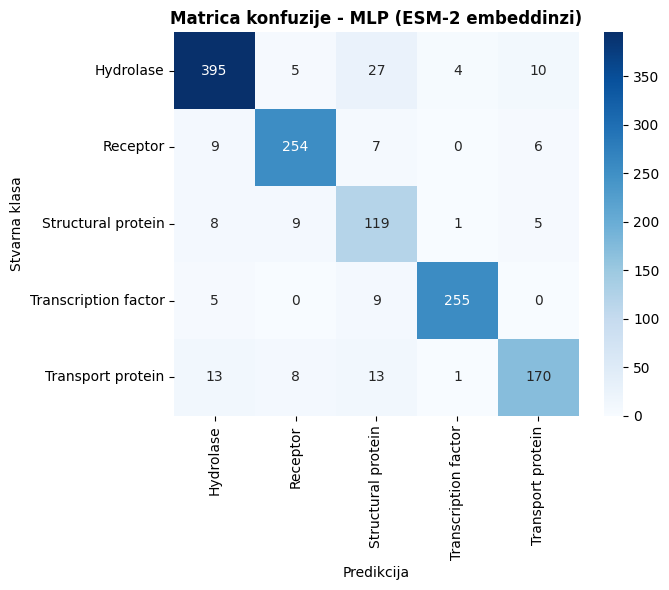

In [36]:
cm = confusion_matrix(y_sc_test, y_pred_sc_dl)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=le.classes_, yticklabels=le.classes_
)
plt.title("Matrica konfuzije - MLP (ESM-2 embeddinzi)", fontweight="bold")
plt.xlabel("Predikcija")
plt.ylabel("Stvarna klasa")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "fig_dl_sc_confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()

## Eksperiment C: MC + klasični ML (notebook 07)

In [16]:
mc_classical_results = pd.read_csv(os.path.join(RESULTS_DIR, "mc_classical_modeling_results.csv"))
best_mc_classical = mc_classical_results.sort_values("CV F1 micro", ascending=False).iloc[0]

print(f"Najbolja kombinacija: {best_mc_classical['Model']} + {best_mc_classical['Feature set']}")
print(f"Parametri: {best_mc_classical['Best params']}\n")

Najbolja kombinacija: SVM + TFIDF-SVD
Parametri: {'estimator__C': 10, 'estimator__kernel': 'rbf'}



### Rekonstrukcija MC test obilježja

In [25]:
entries_mc_train = pd.read_csv(os.path.join(FEATURES_DIR, "mc_train_entries.csv"))["Entry"].values
entries_mc_test = pd.read_csv(os.path.join(FEATURES_DIR, "mc_test_entries.csv"))["Entry"].values

# MultiLabelBinarizer fitovan jednom u 03 (nema ponovnog fitovanja)
mlb = joblib.load(os.path.join(FEATURES_DIR, "mc_label_binarizer.pkl"))
label_columns = list(mlb.classes_)

mc_labels_df = pd.read_csv(os.path.join(FEATURES_DIR, "mc_labels.csv"), index_col="Entry")
y_mc_test = mc_labels_df.loc[entries_mc_test, label_columns].values

mc_test_aac = aac_df.loc[entries_mc_test].values
mc_test_tfidf = np.load(os.path.join(FEATURES_DIR, "mc_test_tfidf_svd.npy"))
mc_test_ph = np.load(os.path.join(FEATURES_DIR, "mc_test_physchem_scaled.npy"))

feature_sets_test_mc = {
    "AAC-CV": mc_test_aac,
    "TFIDF-SVD": mc_test_tfidf,
    "PH": mc_test_ph,
    "AAC-CV+TFIDF-SVD": np.hstack([mc_test_aac, mc_test_tfidf]),
    "AAC-CV+PH": np.hstack([mc_test_aac, mc_test_ph]),
    "TFIDF-SVD+PH": np.hstack([mc_test_tfidf, mc_test_ph]),
    "AAC-CV+TFIDF-SVD+PH": np.hstack([mc_test_aac, mc_test_tfidf, mc_test_ph]),
}

print(f"Test skup (MC): {len(entries_mc_test)} proteina")

Test skup (MC): 1400 proteina


### Finalni classification report 

In [28]:
best_mc_model_path = os.path.join(
    MODELS_DIR, f"mc_{best_mc_classical['Model']}_{best_mc_classical['Feature set']}.pkl"
)

best_mc_classical_model = joblib.load(best_mc_model_path)
X_test_best_mc = feature_sets_test_mc[best_mc_classical["Feature set"]]

y_pred_mc_classical = best_mc_classical_model.predict(X_test_best_mc)

print(f"Eksperiment C: {best_mc_classical['Model']} + {best_mc_classical['Feature set']} \n")
print(classification_report(y_mc_test, y_pred_mc_classical, target_names=label_columns, zero_division=0))

Eksperiment C: SVM + TFIDF-SVD 

                      precision    recall  f1-score   support

           Hydrolase       0.76      0.89      0.82       481
            Receptor       0.81      0.82      0.82       320
  Structural protein       0.97      0.58      0.72       154
Transcription factor       0.94      0.92      0.93       283
   Transport protein       0.81      0.74      0.77       248

           micro avg       0.83      0.82      0.83      1486
           macro avg       0.86      0.79      0.81      1486
        weighted avg       0.84      0.82      0.82      1486
         samples avg       0.81      0.83      0.81      1486



## Eksperiment D: MC + Deep Learning (notebook 08)

In [29]:
with open(os.path.join(MODELS_DIR, "mc_dl_mlp_config.json")) as f:
    mc_dl_config = json.load(f)

mc_dl_model = build_mlp(
    mc_dl_config["input_dim"], mc_dl_config["num_classes"],
    mc_dl_config["hidden_dims"], mc_dl_config["dropout"]
).to(DEVICE)

mc_dl_model.load_state_dict(
    torch.load(os.path.join(MODELS_DIR, "mc_dl_mlp_esm2.pt"), map_location=DEVICE)
)

mc_dl_model.eval()

# Scaler fitovan na MC train podskupu u 08 (nema ponovnog fitovanja)
mc_dl_scaler = joblib.load(os.path.join(MODELS_DIR, "mc_dl_embedding_scaler.pkl"))

X_mc_test_emb = embeddings_df.loc[entries_mc_test].values.astype(np.float32)
X_mc_test_emb_scaled = mc_dl_scaler.transform(X_mc_test_emb)

# Per-class pragovi optimizovani na val skupu u 08
thresholds_mc = np.array(mc_dl_config["thresholds"])

with torch.no_grad():
    logits_mc_dl = mc_dl_model(
        torch.tensor(X_mc_test_emb_scaled, dtype=torch.float32).to(DEVICE)
    )
    probs_mc_dl = torch.sigmoid(logits_mc_dl).cpu().numpy()
    y_pred_mc_dl = (probs_mc_dl >= thresholds_mc).astype(int)

print("Eksperiment D: MLP + ESM-2 embeddings\n")
print(classification_report(y_mc_test, y_pred_mc_dl, target_names=label_columns, zero_division=0))

Eksperiment D: MLP + ESM-2 embeddings

                      precision    recall  f1-score   support

           Hydrolase       0.93      0.90      0.91       481
            Receptor       0.91      0.86      0.88       320
  Structural protein       0.79      0.83      0.81       154
Transcription factor       0.97      0.94      0.96       283
   Transport protein       0.87      0.87      0.87       248

           micro avg       0.91      0.89      0.90      1486
           macro avg       0.90      0.88      0.89      1486
        weighted avg       0.91      0.89      0.90      1486
         samples avg       0.90      0.90      0.90      1486



## Finalno poređenje sva četiri eksperimenta

In [30]:
sc_summary_df = pd.DataFrame([
    {
        "Eksperiment": "A: SC + Klasicni ML",
        "Konfiguracija": f"{best_sc_classical['Model']} + {best_sc_classical['Feature set']}",
        "Test Accuracy": accuracy_score(y_sc_test, y_pred_sc_classical),
        "Test F1 (weighted)": f1_score(y_sc_test, y_pred_sc_classical, average="weighted"),
    },
    {
        "Eksperiment": "B: SC + Deep Learning",
        "Konfiguracija": "MLP + ESM-2 embeddings",
        "Test Accuracy": accuracy_score(y_sc_test, y_pred_sc_dl),
        "Test F1 (weighted)": f1_score(y_sc_test, y_pred_sc_dl, average="weighted"),
    },
])

mc_summary_df = pd.DataFrame([
    {
        "Eksperiment": "C: MC + Klasicni ML",
        "Konfiguracija": f"{best_mc_classical['Model']} + {best_mc_classical['Feature set']}",
        "Test F1 micro": f1_score(y_mc_test, y_pred_mc_classical, average="micro", zero_division=0),
        "Test F1 macro": f1_score(y_mc_test, y_pred_mc_classical, average="macro", zero_division=0),
        "Test Subset Accuracy": accuracy_score(y_mc_test, y_pred_mc_classical),
        "Test Hamming Loss": hamming_loss(y_mc_test, y_pred_mc_classical),
    },
    {
        "Eksperiment": "D: MC + Deep Learning",
        "Konfiguracija": "MLP + ESM-2 embeddings",
        "Test F1 micro": f1_score(y_mc_test, y_pred_mc_dl, average="micro", zero_division=0),
        "Test F1 macro": f1_score(y_mc_test, y_pred_mc_dl, average="macro", zero_division=0),
        "Test Subset Accuracy": accuracy_score(y_mc_test, y_pred_mc_dl),
        "Test Hamming Loss": hamming_loss(y_mc_test, y_pred_mc_dl),
    },
])

print("SC eksperimenti (A vs. B):\n")
print(sc_summary_df.to_string(index=False))
print("\nMC eksperimenti (C vs. D):\n")
print(mc_summary_df.to_string(index=False))

SC eksperimenti (A vs. B):

          Eksperiment          Konfiguracija  Test Accuracy  Test F1 (weighted)
  A: SC + Klasicni ML SVM + AAC-CV+TFIDF-SVD       0.818455            0.815547
B: SC + Deep Learning MLP + ESM-2 embeddings       0.894974            0.896819

MC eksperimenti (C vs. D):

          Eksperiment          Konfiguracija  Test F1 micro  Test F1 macro  Test Subset Accuracy  Test Hamming Loss
  C: MC + Klasicni ML        SVM + TFIDF-SVD       0.825236       0.813127              0.742857              0.074
D: MC + Deep Learning MLP + ESM-2 embeddings       0.897514       0.887541              0.864286              0.043


### Vizualizacija: klasični ML vs. Deep Learning 

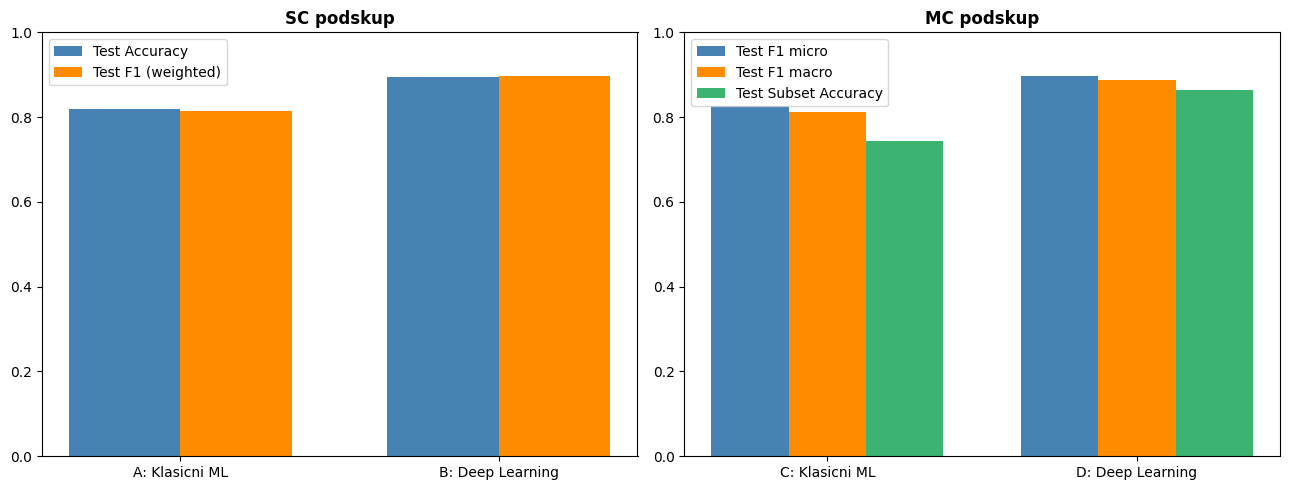

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# SC podskup
x_sc = np.arange(len(sc_summary_df))
width = 0.35
axes[0].bar(x_sc - width/2, sc_summary_df["Test Accuracy"], width, label="Test Accuracy", color="steelblue")
axes[0].bar(x_sc + width/2, sc_summary_df["Test F1 (weighted)"], width, label="Test F1 (weighted)", color="darkorange")
axes[0].set_xticks(x_sc)
axes[0].set_xticklabels(["A: Klasicni ML", "B: Deep Learning"])
axes[0].set_ylim(0, 1)
axes[0].set_title("SC podskup", fontweight="bold")
axes[0].legend()

# MC podskup
x_mc = np.arange(len(mc_summary_df))
width = 0.25
axes[1].bar(x_mc - width, mc_summary_df["Test F1 micro"], width, label="Test F1 micro", color="steelblue")
axes[1].bar(x_mc, mc_summary_df["Test F1 macro"], width, label="Test F1 macro", color="darkorange")
axes[1].bar(x_mc + width, mc_summary_df["Test Subset Accuracy"], width, label="Test Subset Accuracy", color="mediumseagreen")
axes[1].set_xticks(x_mc)
axes[1].set_xticklabels(["C: Klasicni ML", "D: Deep Learning"])
axes[1].set_ylim(0, 1)
axes[1].set_title("MC podskup", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "fig_final_comparison_all_experiments.png"), dpi=300, bbox_inches="tight")
plt.show()

### Overfitting gap kroz sva četiri eksperimenta

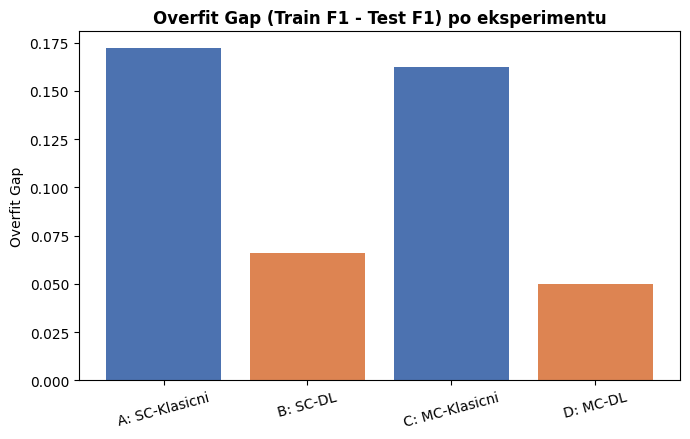

   Eksperiment  Overfit Gap (F1)
A: SC-Klasicni          0.172251
      B: SC-DL          0.065821
C: MC-Klasicni          0.162139
      D: MC-DL          0.050106


In [35]:
overfit_gap_df = pd.DataFrame([
    {"Eksperiment": "A: SC-Klasicni", "Overfit Gap (F1)": best_sc_classical["Train F1 (weighted)"] - best_sc_classical["Test F1 (weighted)"]},
    {"Eksperiment": "B: SC-DL", "Overfit Gap (F1)": pd.read_csv(os.path.join(RESULTS_DIR, "sc_dl_modeling_results.csv"))["Overfit Gap (F1)"].iloc[0]},
    {"Eksperiment": "C: MC-Klasicni", "Overfit Gap (F1)": best_mc_classical["Train F1 micro"] - best_mc_classical["Test F1 micro"]},
    {"Eksperiment": "D: MC-DL", "Overfit Gap (F1)": pd.read_csv(os.path.join(RESULTS_DIR, "mc_dl_modeling_results.csv"))["Overfit Gap (F1 micro)"].iloc[0]},
])

plt.figure(figsize=(7, 4.5))
colors = ["#4C72B0", "#DD8452", "#4C72B0", "#DD8452"]
plt.bar(overfit_gap_df["Eksperiment"], overfit_gap_df["Overfit Gap (F1)"], color=colors)
plt.title("Overfit Gap (Train F1 - Test F1) po eksperimentu", fontweight="bold")
plt.ylabel("Overfit Gap")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "fig_overfit_gap_comparison.png"), dpi=300, bbox_inches="tight")
plt.show()

print(overfit_gap_df.to_string(index=False))

### Čuvanje finalnog sažetka rezultata

In [34]:
sc_summary_df.to_csv(os.path.join(RESULTS_DIR, "final_summary_sc.csv"), index=False)
mc_summary_df.to_csv(os.path.join(RESULTS_DIR, "final_summary_mc.csv"), index=False)
overfit_gap_df.to_csv(os.path.join(RESULTS_DIR, "final_summary_overfit_gap.csv"), index=False)

print("Finalni rezultati sacuvani u '../data/results/'.")

Finalni rezultati sacuvani u '../data/results/'.
